In [3]:
import pandas as pd

For questions 3 to 5:  
Given a dataset with treatment and control data having “before” and “after” parts, apply a differences-in-differences regression.  
Use homework_3.2.a.csv and homework_3.2.b.csv. 

In [5]:
df_a = pd.read_csv('homework_3.2.a.csv')
df_a

,group1,time1,outcome1
0,0,0,0.882026
1,0,1,1.600079
2,0,0,0.489369
3,0,1,2.520447
4,0,0,0.933779
...,...,...,...
995,1,1,4.306435
996,1,0,1.900801
997,1,1,4.147096
998,1,0,1.426195


In [6]:
df_b = pd.read_csv('homework_3.2.b.csv')
df_b

,group2,time2,outcome2
0,0,0,0.667155
1,0,1,2.470969
2,0,0,-0.506778
3,0,1,1.525657
4,0,0,0.273664
...,...,...,...
995,1,1,4.637301
996,1,0,3.681828
997,1,1,4.710121
998,1,0,0.629718


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Reproducibility
np.random.seed(42)

# ----------------------------
# Create synthetic DiD data
# ----------------------------

before_dates = pd.date_range("2026-02-01", "2026-04-30", freq="D")
after_dates = pd.date_range("2026-05-01", "2026-07-31", freq="D")

cities = ["Boston", "NYC"]

# Approximate daily accidents per 100,000 people
# 500/year -> about 1.37/day
# 1000/year -> about 2.74/day
boston_before_mean = 500 / 365
nyc_before_mean = 1000 / 365

# Summer increases accidents in both cities
summer_increase = 0.8

# Boston law reduces part of the summer increase
boston_policy_offset = -0.4

rows = []

# Before period
for city in cities:
    base_mean = boston_before_mean if city == "Boston" else nyc_before_mean
    
    for date in before_dates:
        y = np.random.poisson(lam=base_mean)
        rows.append({
            "date": date,
            "city": city,
            "treated": 1 if city == "Boston" else 0,
            "after": 0,
            "treated_after": 0,
            "accidents_per_100k": y
        })

# After period
for city in cities:
    base_mean = boston_before_mean if city == "Boston" else nyc_before_mean
    
    for date in after_dates:
        if city == "Boston":
            lam = base_mean + summer_increase + boston_policy_offset
        else:
            lam = base_mean + summer_increase
        
        lam = max(lam, 0.01)
        y = np.random.poisson(lam=lam)
        
        rows.append({
            "date": date,
            "city": city,
            "treated": 1 if city == "Boston" else 0,
            "after": 1,
            "treated_after": 1 if city == "Boston" else 0,
            "accidents_per_100k": y
        })

df = pd.DataFrame(rows)

# ----------------------------
# Fit the basic linear regression DiD model
# ----------------------------
# accidents_per_100k = beta0 + beta1*treated + beta2*after + beta3*treated_after + error
model = smf.ols(
    "accidents_per_100k ~ treated + after + treated_after",
    data=df
).fit(cov_type="HC1")

# ----------------------------
# Print results
# ----------------------------

print("\n=== Difference-in-Differences Linear Regression Summary ===\n")
print(model.summary())

print("\n=== Coefficients ===")
print(model.params)

print("\n=== Robust Standard Errors ===")
print(model.bse)

print("\n=== 95% Confidence Intervals ===")
print(model.conf_int())

# ----------------------------
# Group means for interpretation
# ----------------------------

group_means = (
    df.groupby(["city", "after"])["accidents_per_100k"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

print("\n=== Group Means ===")
print(group_means)

pivot = df.pivot_table(
    values="accidents_per_100k",
    index="city",
    columns="after",
    aggfunc="mean"
)
pivot.columns = ["Before" if c == 0 else "After" for c in pivot.columns]

print("\n=== Mean Accidents per 100k by City and Period ===")
print(pivot)

# ----------------------------
# Manual DiD calculation
# ----------------------------

boston_before = df[(df["city"] == "Boston") & (df["after"] == 0)]["accidents_per_100k"].mean()
boston_after = df[(df["city"] == "Boston") & (df["after"] == 1)]["accidents_per_100k"].mean()
nyc_before = df[(df["city"] == "NYC") & (df["after"] == 0)]["accidents_per_100k"].mean()
nyc_after = df[(df["city"] == "NYC") & (df["after"] == 1)]["accidents_per_100k"].mean()

did = (boston_after - boston_before) - (nyc_after - nyc_before)

print("\n=== Manual Difference-in-Differences Calculation ===")
print(f"Boston before: {boston_before:.4f}")
print(f"Boston after:  {boston_after:.4f}")
print(f"NYC before:    {nyc_before:.4f}")
print(f"NYC after:     {nyc_after:.4f}")
print(f"Boston change: {boston_after - boston_before:.4f}")
print(f"NYC change:    {nyc_after - nyc_before:.4f}")
print(f"DiD estimate:  {did:.4f}")

print("\n=== Interpretation ===")
print(f"Intercept (beta0): {model.params['Intercept']:.4f}")
print(f"Treated (beta1): {model.params['treated']:.4f}")
print(f"After (beta2): {model.params['after']:.4f}")
print(f"Treated x After (beta3, DiD effect): {model.params['treated_after']:.4f}")

# ----------------------------
# Plot with Boston and NYC labels
# ----------------------------

plot_df = (
    df.groupby(["date", "city"], as_index=False)["accidents_per_100k"]
      .mean()
)

plt.figure(figsize=(12, 6))

for city, color in [("Boston", "tab:blue"), ("NYC", "tab:orange")]:
    sub = plot_df[plot_df["city"] == city]
    plt.plot(sub["date"], sub["accidents_per_100k"], label=city, color=color, linewidth=2)

plt.axvline(pd.Timestamp("2026-05-01"), color="black", linestyle="--", linewidth=1.5)
plt.text(pd.Timestamp("2026-05-02"), plt.ylim()[1] * 0.95, "Law begins / After period", fontsize=10)

plt.title("Daily Accidents per 100,000: Boston vs NYC")
plt.xlabel("Date")
plt.ylabel("Accidents per 100,000")
plt.legend(title="City")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Sample rows
# ----------------------------

print("\n=== Sample Data ===")
print(df.head(10))

               ANALYZING DATASET 1                
                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2807.
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:10:38   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

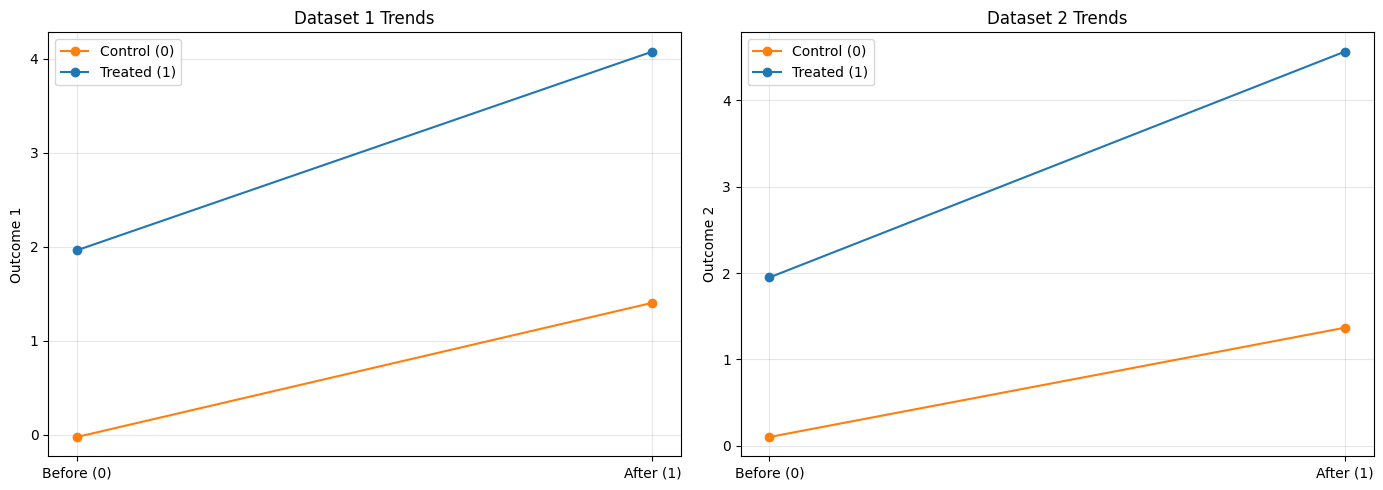

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 1. Load your datasets
df_a = pd.read_csv('homework_3.2.a.csv')
df_b = pd.read_csv('homework_3.2.b.csv')

# --------------------------------------------------------
# ANALYZE DATASET 1 (df_a)
# --------------------------------------------------------
print("==================================================")
print("               ANALYZING DATASET 1                ")
print("==================================================")

# Create the interaction term for DiD
df_a['interaction1'] = df_a['group1'] * df_a['time1']

# Fit the linear regression model with robust standard errors
model_a = smf.ols(
    "outcome1 ~ group1 + time1 + interaction1",
    data=df_a
).fit(cov_type="HC1")

print(model_a.summary())

# Manual DiD calculation for Dataset 1
mean_a = df_a.groupby(['group1', 'time1'])['outcome1'].mean()
did_a = (mean_a[1][1] - mean_a[1][0]) - (mean_a[0][1] - mean_a[0][0])

print("\n--- Manual DiD Calculation (Dataset 1) ---")
print(f"Control (0) Before (0): {mean_a[0][0]:.4f}")
print(f"Control (0) After (1):  {mean_a[0][1]:.4f}")
print(f"Treated (1) Before (0): {mean_a[1][0]:.4f}")
print(f"Treated (1) After (1):  {mean_a[1][1]:.4f}")
print(f"DiD Treatment Effect (Beta3): {did_a:.4f}\n\n")


# --------------------------------------------------------
# ANALYZE DATASET 2 (df_b)
# --------------------------------------------------------
print("==================================================")
print("               ANALYZING DATASET 2                ")
print("==================================================")

# Create the interaction term for DiD
df_b['interaction2'] = df_b['group2'] * df_b['time2']

# Fit the linear regression model with robust standard errors
model_b = smf.ols(
    "outcome2 ~ group2 + time2 + interaction2",
    data=df_b
).fit(cov_type="HC1")

print(model_b.summary())

# Manual DiD calculation for Dataset 2
mean_b = df_b.groupby(['group2', 'time2'])['outcome2'].mean()
did_b = (mean_b[1][1] - mean_b[1][0]) - (mean_b[0][1] - mean_b[0][0])

print("\n--- Manual DiD Calculation (Dataset 2) ---")
print(f"Control (0) Before (0): {mean_b[0][0]:.4f}")
print(f"Control (0) After (1):  {mean_b[0][1]:.4f}")
print(f"Treated (1) Before (0): {mean_b[1][0]:.4f}")
print(f"Treated (1) After (1):  {mean_b[1][1]:.4f}")
print(f"DiD Treatment Effect (Beta3): {did_b:.4f}\n\n")


# --------------------------------------------------------
# DIRECT COMPARISON SUMMARY
# --------------------------------------------------------
print("==================================================")
print("                FINAL COMPARISON                  ")
print("==================================================")
print(f"Dataset 1 Treatment Effect: {model_a.params['interaction1']:.4f}")
print(f"Dataset 2 Treatment Effect: {model_b.params['interaction2']:.4f}")

largest_dataset = "Dataset 1" if abs(model_a.params['interaction1']) > abs(model_b.params['interaction2']) else "Dataset 2"
print(f"\nConclusion for Q3: {largest_dataset} has the largest treatment effect.")


# --------------------------------------------------------
# VISUALIZATION (Optional)
# --------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Dataset 1
ax1.plot([0, 1], [mean_a[0][0], mean_a[0][1]], marker='o', label='Control (0)', color='tab:orange')
ax1.plot([0, 1], [mean_a[1][0], mean_a[1][1]], marker='o', label='Treated (1)', color='tab:blue')
ax1.set_title("Dataset 1 Trends")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Before (0)', 'After (1)'])
ax1.set_ylabel('Outcome 1')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Dataset 2
ax2.plot([0, 1], [mean_b[0][0], mean_b[0][1]], marker='o', label='Control (0)', color='tab:orange')
ax2.plot([0, 1], [mean_b[1][0], mean_b[1][1]], marker='o', label='Treated (1)', color='tab:blue')
ax2.set_title("Dataset 2 Trends")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before (0)', 'After (1)'])
ax2.set_ylabel('Outcome 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Q3. Which dataset likely has the largest treatment effect, assuming that the treatment and control groups have parallel trends? 

A3. Dataset 2

Q4. Using the standard errors for regression, which dataset has the most statistically significant (and nonzero) treatment effect? 

In [12]:
dataset_1_coef = model_a.params['interaction1']
dataset_1_standard_error = model_a.bse['interaction1']
dataset_1_coef, dataset_1_standard_error

(np.float64(0.6858469689823663), np.float64(0.06251264175031666))

In [13]:
dataset_2_coef = model_b.params['interaction2']
dataset_2_standard_error = model_b.bse['interaction2']
dataset_2_coef, dataset_2_standard_error

(np.float64(1.3498589246796788), np.float64(0.147032166603766))

In [14]:
dataset_1_t_stat = dataset_1_coef / dataset_1_standard_error
dataset_2_t_stat = dataset_2_coef / dataset_2_standard_error
dataset_1_t_stat, dataset_2_t_stat

(np.float64(10.971332354209652), np.float64(9.180704847513988))

A. Dataset 1

Q5. Which of these is closest to the treatment effect for group 2? 

A5. It should be around 9.18